<a href="https://www.kaggle.com/code/lalit7881/predicting-student-academic-success-with-ml?scriptVersionId=306049993" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dhruvb2028/student-academic-performance-dataset-for-ml/Students_Performance_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/dhruvb2028/student-academic-performance-dataset-for-ml/Students_Performance_dataset.csv')

In [3]:
df.head()

,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,...,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,...,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,...,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000
2,2020,Female,21,2019,BCSE,5,No,No,3,3,...,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000
3,2021,Male,20,2020,BCSE,4,Yes,No,1,3,...,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488
4,2021,Male,22,2019,BCSE,4,Yes,No,3,1,...,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000


In [4]:
df.tail()

,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,...,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
1189,2021,Female,20,2020,BCSE,8,No,Yes,1,2,...,Data Science,Relationship,Yes,Bachelor,No,2.65,No,3.77,100,180000
1190,2022,Male,23,2020,BCSE,8,Yes,Yes,4,2,...,Software,Single,Yes,Bachelor,No,2.50,No,2.22,18,200000
1191,2021,Male,22,2020,BCSE,9,No,Yes,3,2,...,Hardware,Married,Yes,Family,No,1.56,No,2.78,100,200000
1192,2019,Female,25,2018,BCSE,11,No,Yes,5,3,...,Software,Single,No,Bachelor,No,1.40,No,2.52,136,210000
1193,2018,Female,23,2017,BCSE,11,No,Yes,3,2,...,Hardware,Relationship,Yes,Bachelor,No,1.34,No,2.88,88,250000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 31 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   University Admission year                                                  1194 non-null   int64  
 1   Gender                                                                     1194 non-null   object 
 2   Age                                                                        1194 non-null   int64  
 3   H.S.C passing year                                                         1194 non-null   int64  
 4   Program                                                                    1194 non-null   object 
 5   Current Semester                                                           1194 non-null   int64  
 6   Do you have meritorious scholarship ?                   

In [6]:
df.describe()

,University Admission year,Age,H.S.C passing year,Current Semester,How many hour do you study daily?,How many times do you seat for study in a day?,How many hour do you spent daily in social media?,How many hour do you spent daily on your skill development?,What was your previous SGPA?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
count,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1.194000e+03
mean,2020.515075,21.343384,2019.214405,6.539363,3.131491,1.940536,3.289782,2.185092,2.683945,3.165603,71.842546,6.248812e+04
std,1.354954,1.613338,1.380960,3.809884,1.649597,0.856305,2.289547,1.296101,0.871592,0.750132,48.074338,7.617356e+04
min,2013.000000,18.000000,2012.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+03
25%,2020.000000,20.000000,2019.000000,3.000000,2.000000,1.000000,2.000000,1.000000,2.200000,2.900000,23.000000,3.000000e+04
50%,2021.000000,21.000000,2020.000000,7.000000,3.000000,2.000000,3.000000,2.000000,2.680000,3.210000,78.000000,5.000000e+04
75%,2022.000000,22.000000,2020.000000,10.000000,4.000000,2.000000,4.000000,3.000000,3.380000,3.670000,117.000000,7.400000e+04
max,2023.000000,27.000000,2028.000000,24.000000,13.000000,7.000000,20.000000,12.000000,4.000000,4.000000,145.000000,2.000000e+06


In [7]:
df.isnull().sum()

University Admission year                                                    0
Gender                                                                       0
Age                                                                          0
H.S.C passing year                                                           0
Program                                                                      0
Current Semester                                                             0
Do you have meritorious scholarship ?                                        0
Do you use University transportation?                                        0
How many hour do you study daily?                                            0
How many times do you seat for study in a day?                               0
What is your preferable learning mode?                                       0
Do you use smart phone?                                                      0
Do you have personal Computer?                      

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['University Admission year', 'Gender', 'Age', 'H.S.C passing year',
       'Program', 'Current Semester', 'Do you have meritorious scholarship ?',
       'Do you use University transportation?',
       'How many hour do you study daily?',
       'How many times do you seat for study in a day?',
       'What is your preferable learning mode?', 'Do you use smart phone?',
       'Do you have personal Computer?',
       'How many hour do you spent daily in social media?',
       'Status of your English language proficiency',
       'Average attendance on class', 'Did you ever fall in probation?',
       'Did you ever got suspension?',
       'Do you attend in teacher consultancy for any kind of academical problems?',
       'What are the skills do you have ?',
       'How many hour do you spent daily on your skill development?',
       'What is you interested area?', 'What is your relationship status?',
       'Are you engaged with any co-curriculum activities?',
       'With whom y

In [10]:
df.nunique()

University Admission year                                                     11
Gender                                                                         2
Age                                                                           10
H.S.C passing year                                                            12
Program                                                                        1
Current Semester                                                              22
Do you have meritorious scholarship ?                                          2
Do you use University transportation?                                          2
How many hour do you study daily?                                             12
How many times do you seat for study in a day?                                 8
What is your preferable learning mode?                                         2
Do you use smart phone?                                                        2
Do you have personal Compute

In [11]:
df.dtypes

University Admission year                                                      int64
Gender                                                                        object
Age                                                                            int64
H.S.C passing year                                                             int64
Program                                                                       object
Current Semester                                                               int64
Do you have meritorious scholarship ?                                         object
Do you use University transportation?                                         object
How many hour do you study daily?                                              int64
How many times do you seat for study in a day?                                 int64
What is your preferable learning mode?                                        object
Do you use smart phone?                                          

In [12]:
df.shape

(1194, 31)

## EDA

In [13]:
plt.style.use('ggplot')

In [14]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("?", "")

In [15]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

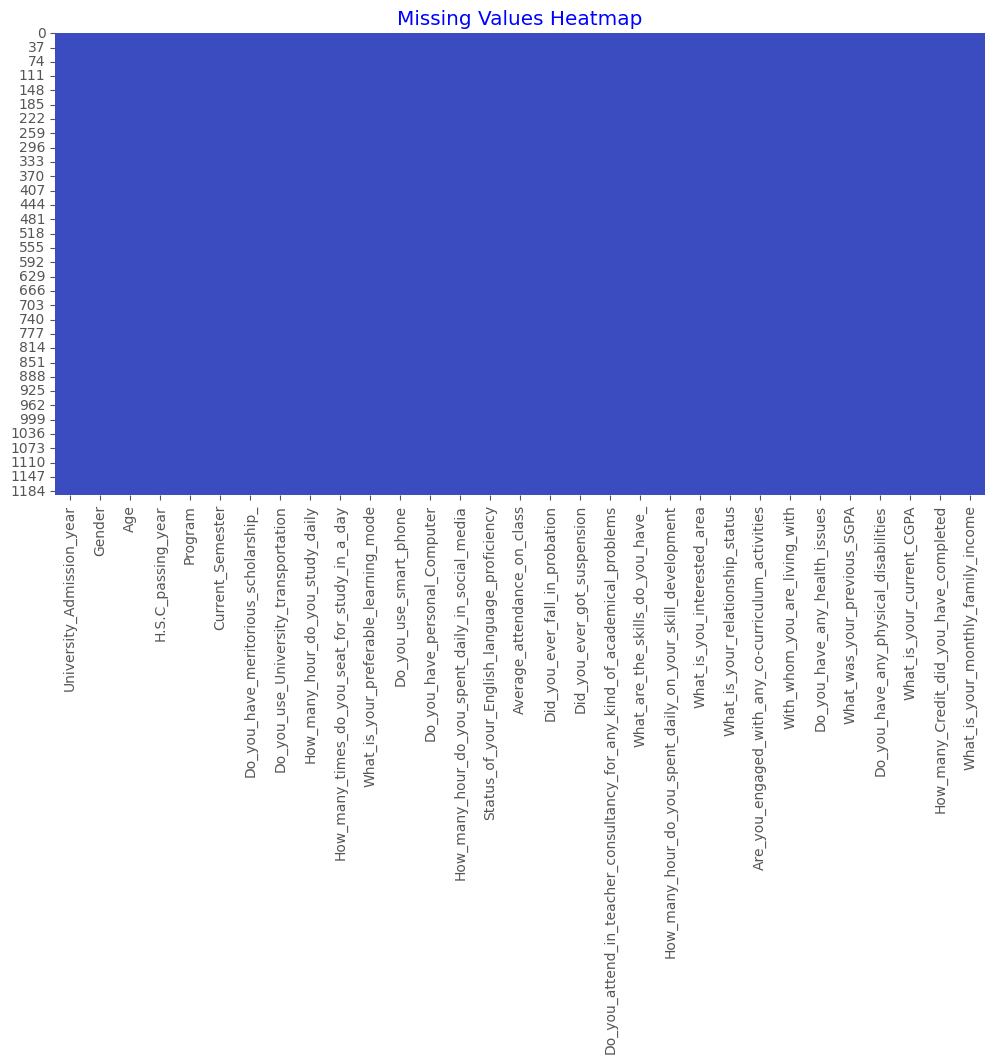

In [16]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cmap="coolwarm", cbar=False)
plt.title("Missing Values Heatmap", color='blue')
plt.show()

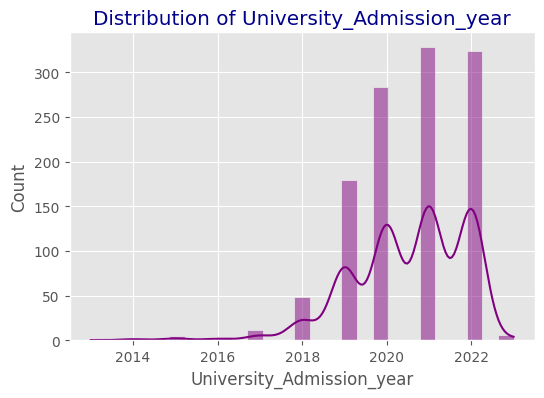

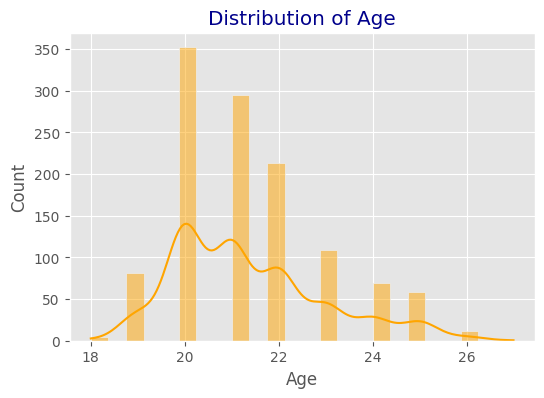

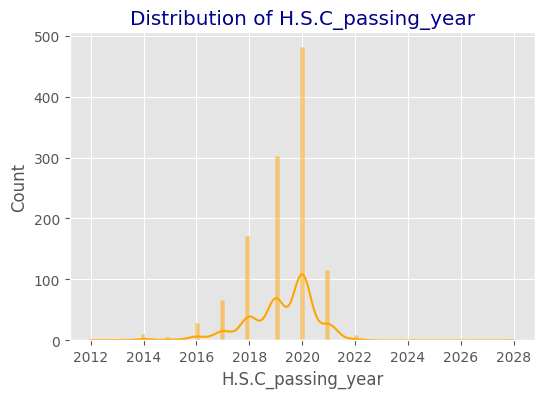

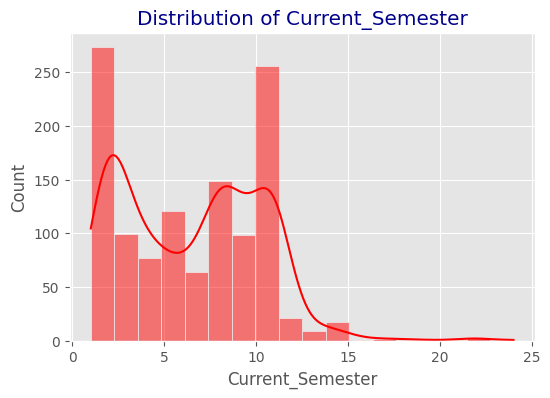

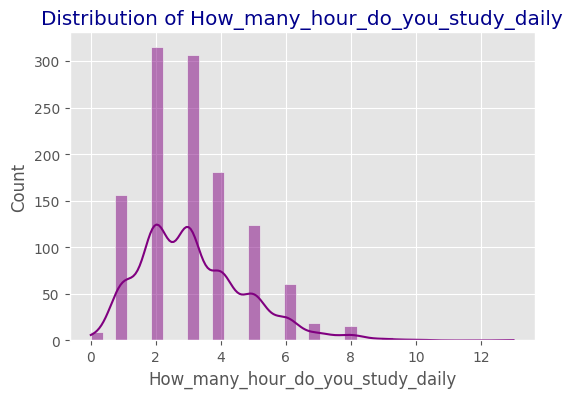

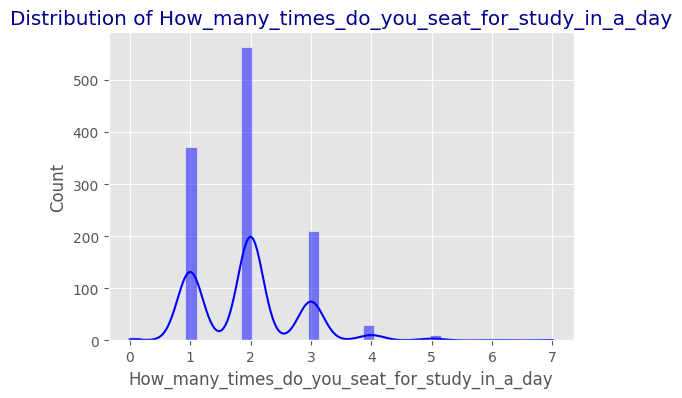

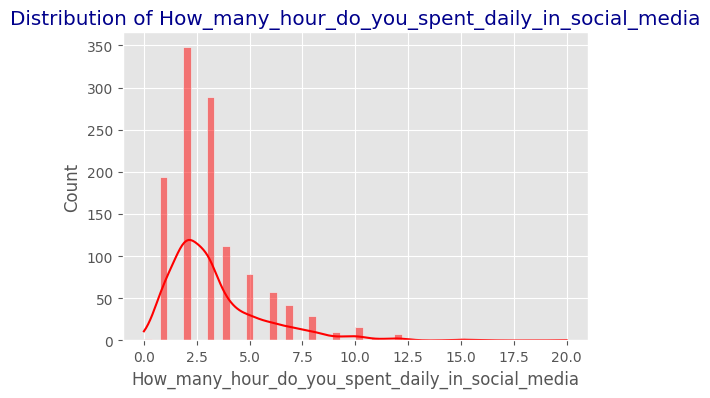

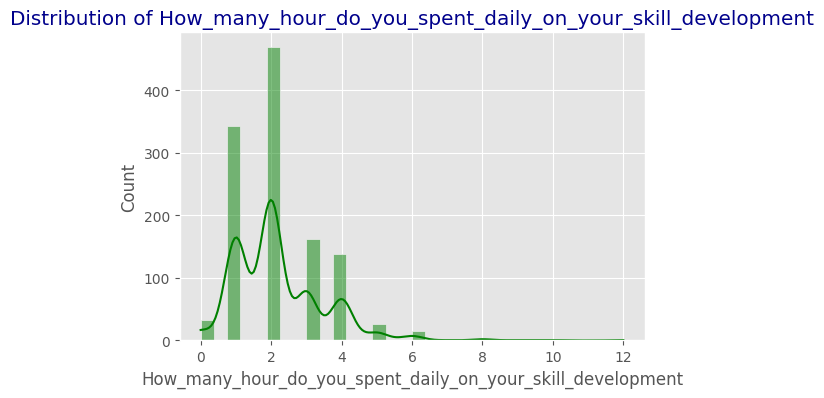

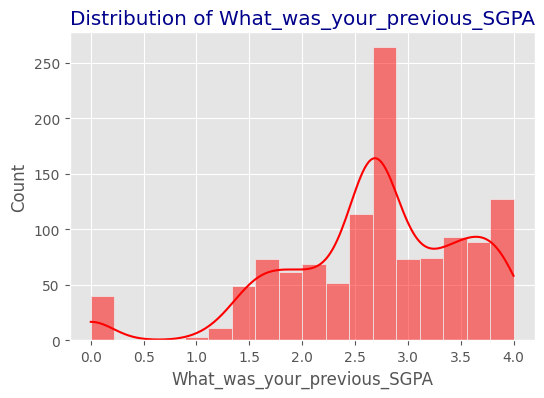

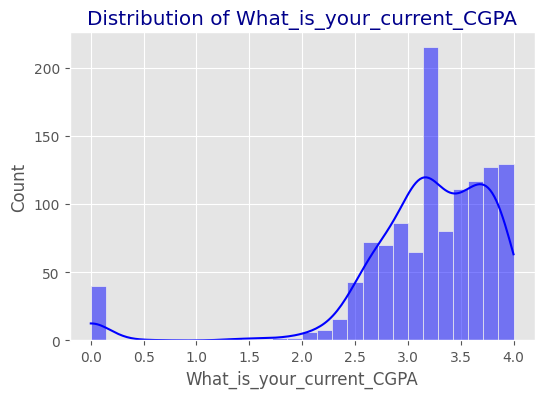

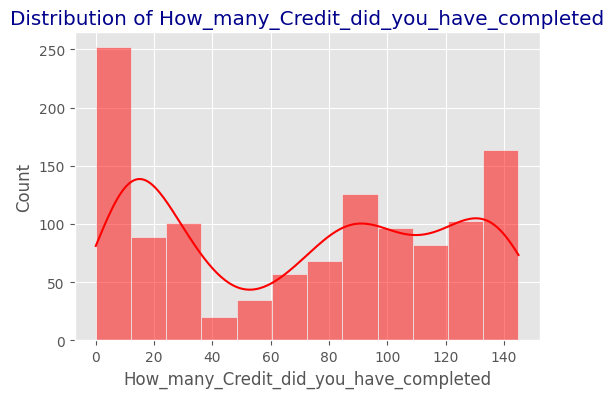

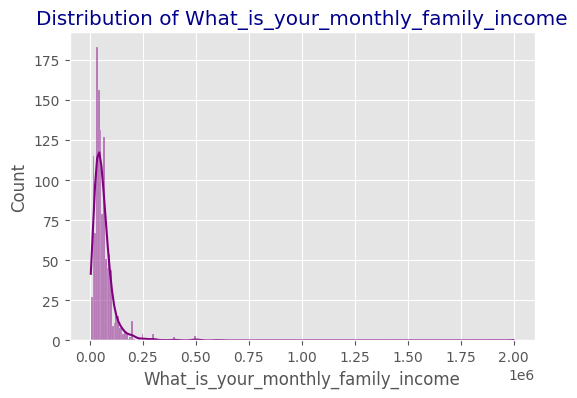

In [17]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color=np.random.choice(['red','blue','green','purple','orange']))
    plt.title(f'Distribution of {col}', color='darkblue')
    plt.show()

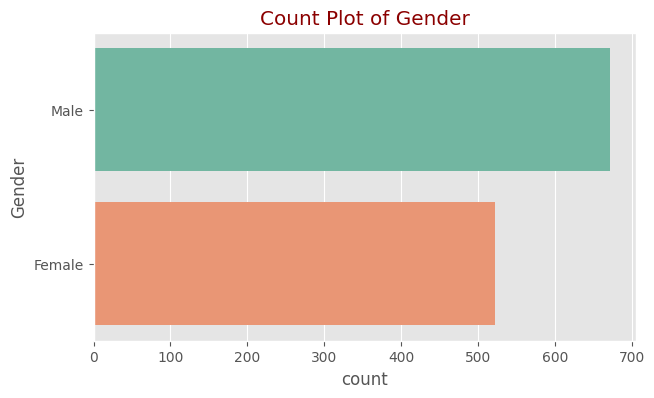

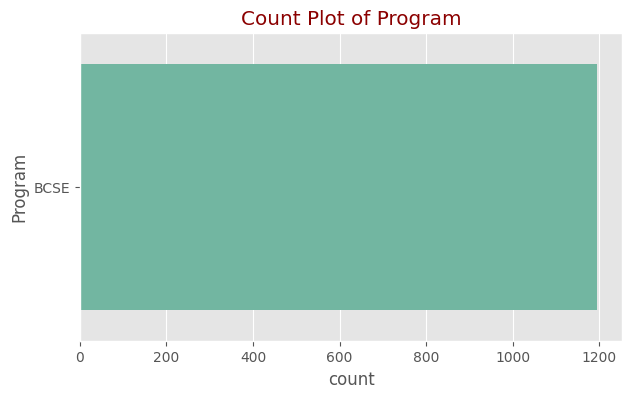

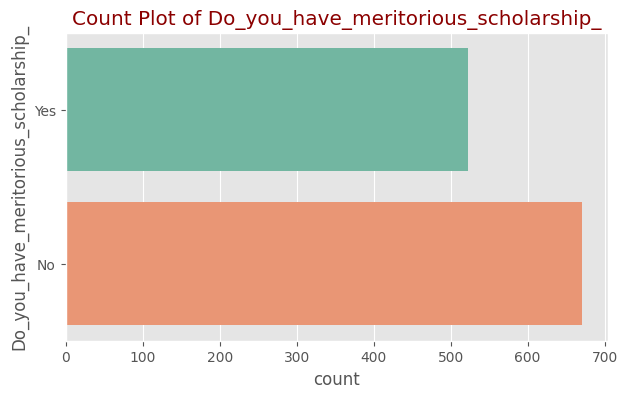

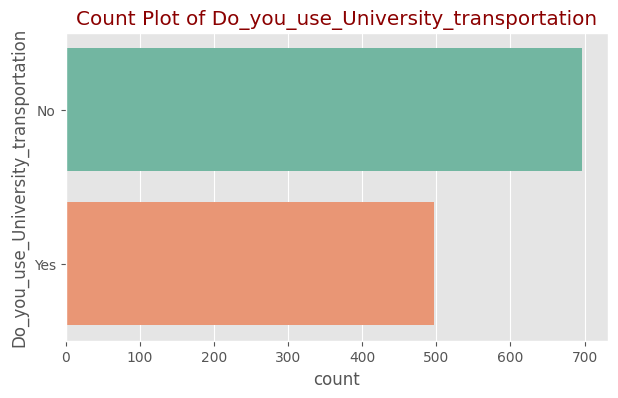

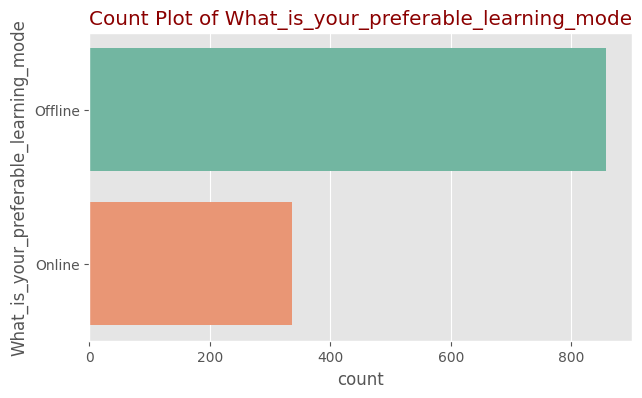

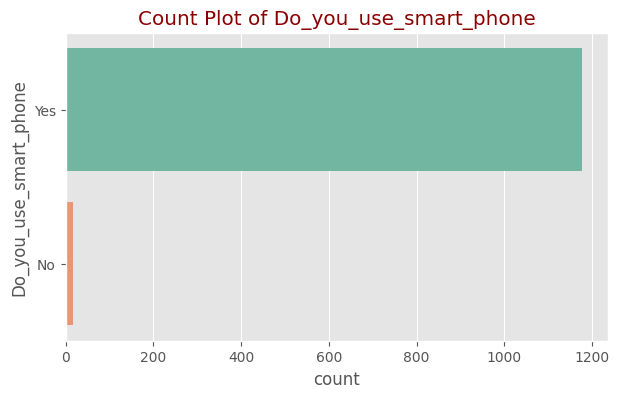

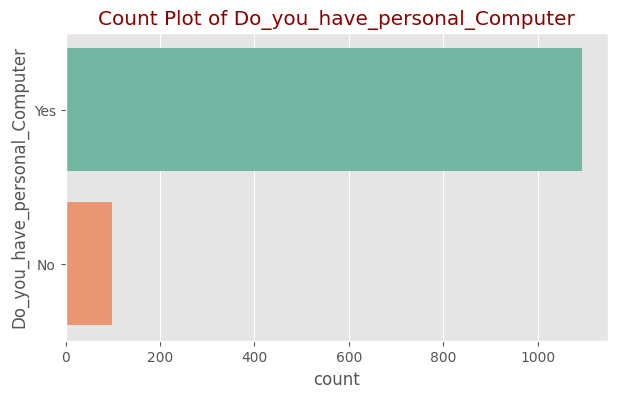

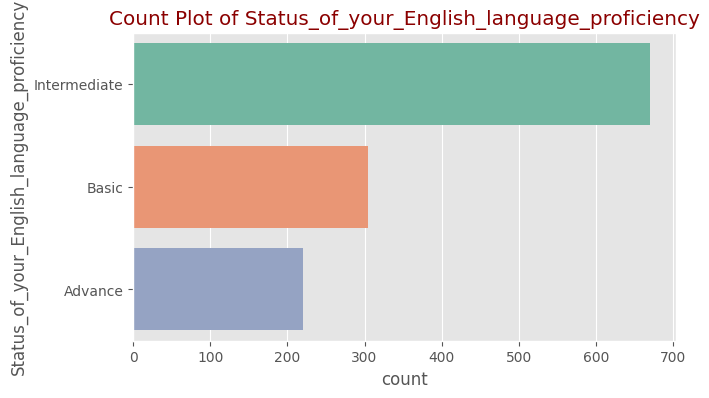

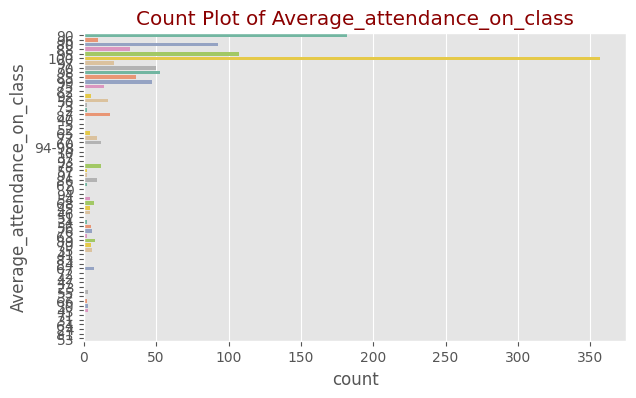

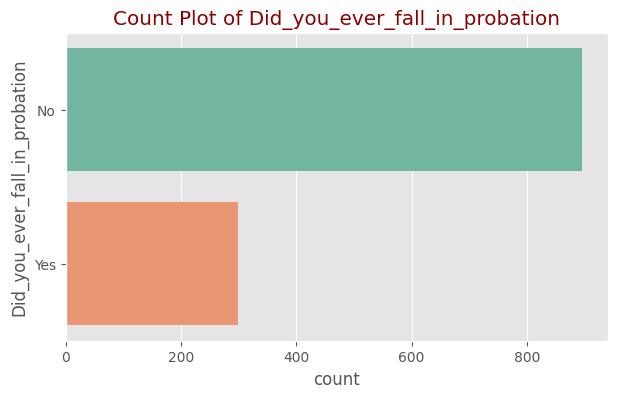

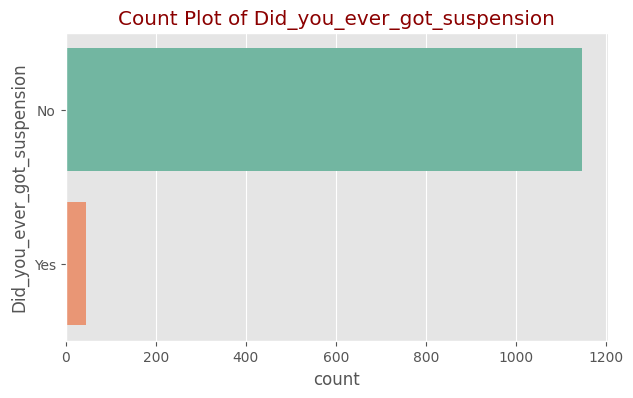

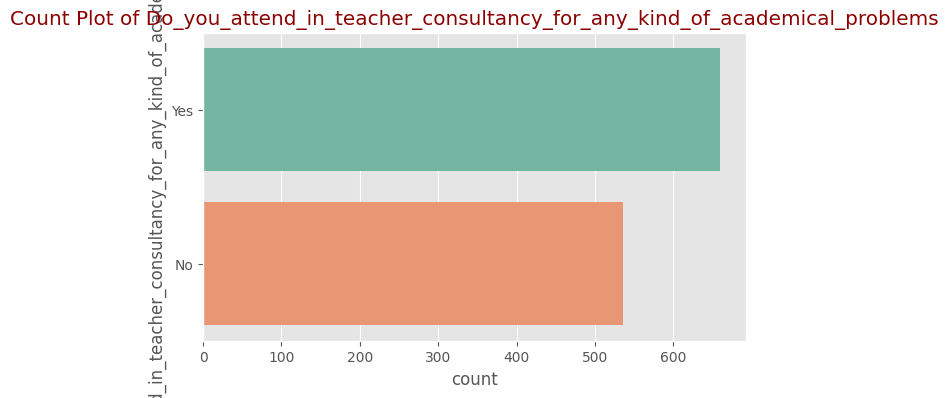

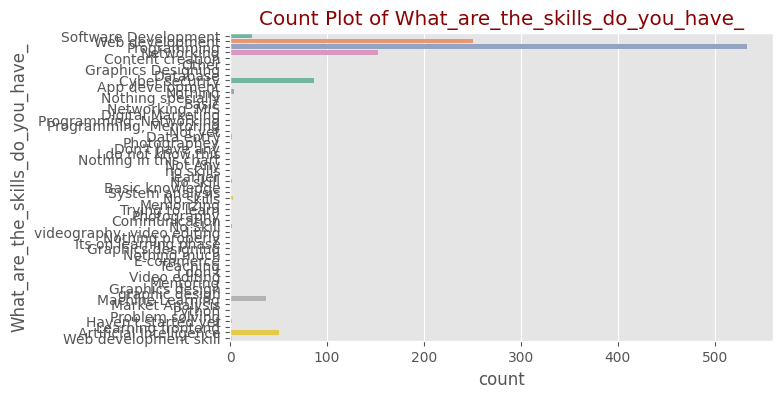

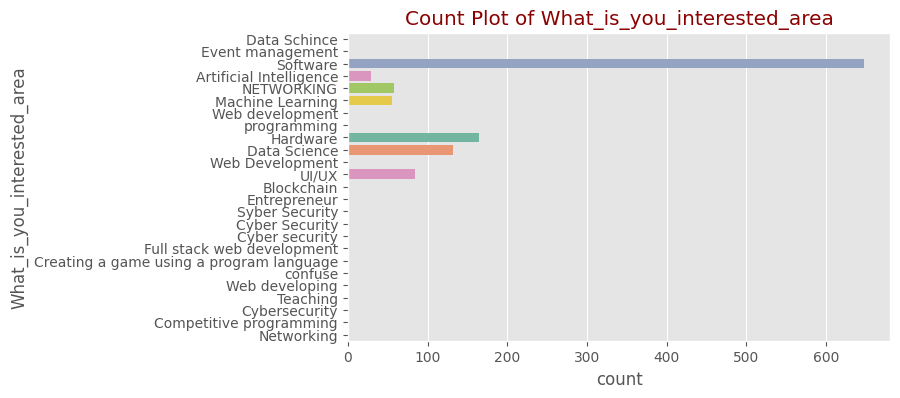

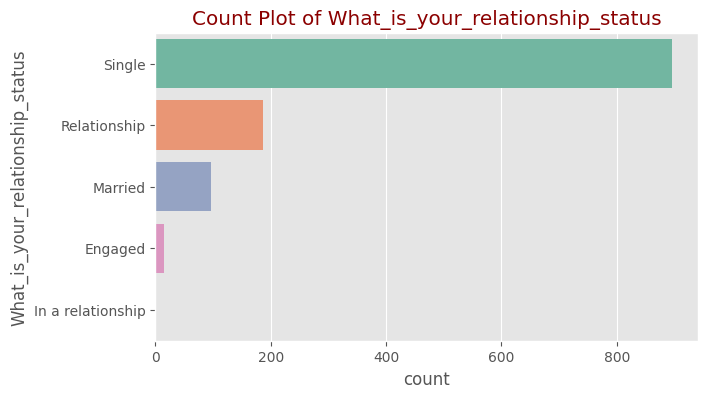

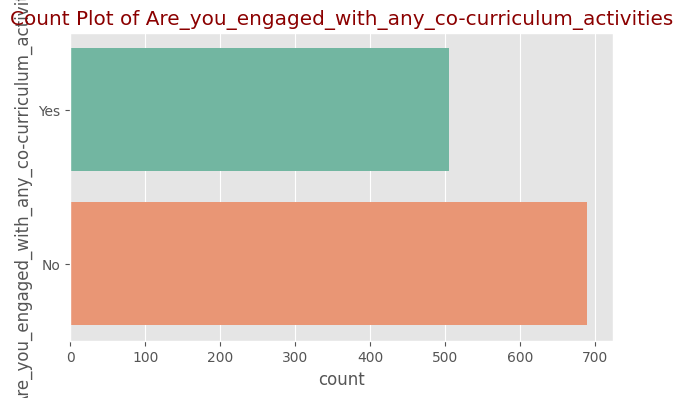

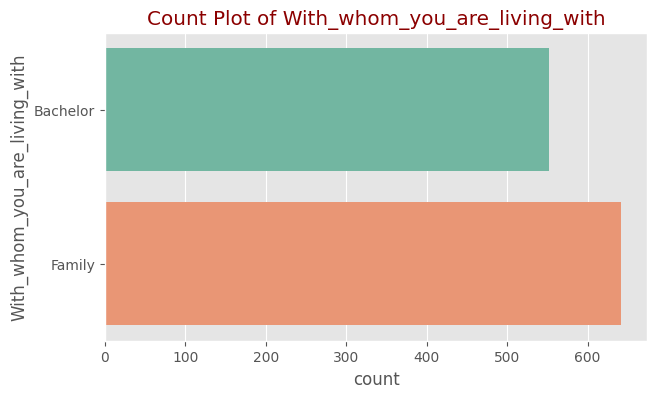

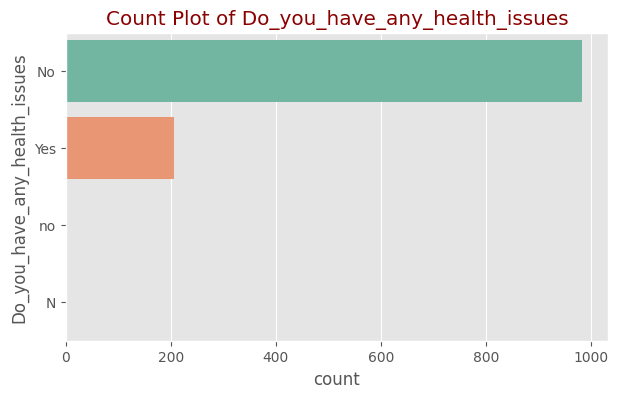

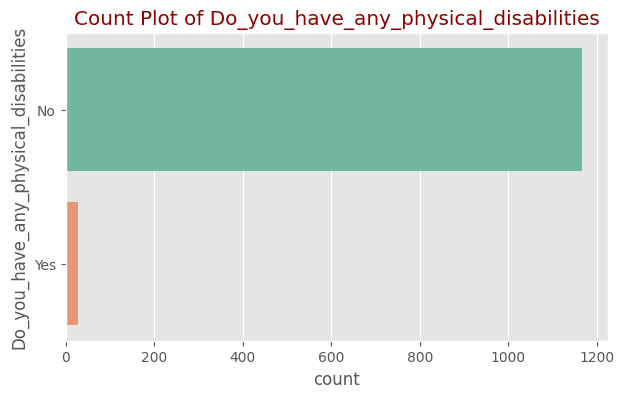

In [18]:
for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(y=df[col], palette='Set2')
    plt.title(f'Count Plot of {col}', color='darkred')
    plt.show()

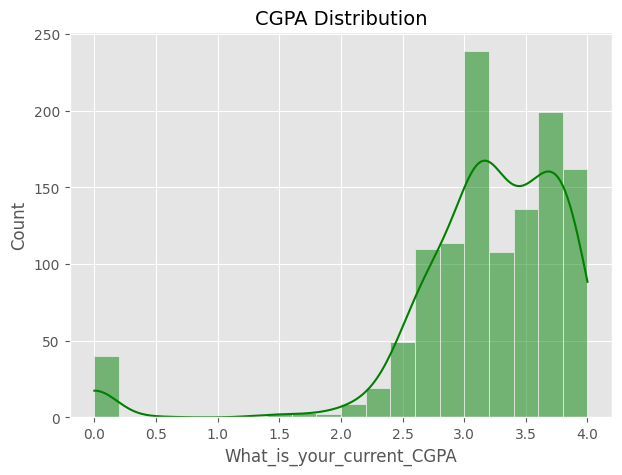

In [19]:
plt.figure(figsize=(7,5))
sns.histplot(df['What_is_your_current_CGPA'], bins=20, kde=True, color='green')
plt.title("CGPA Distribution", fontsize=14, color='black')
plt.show()

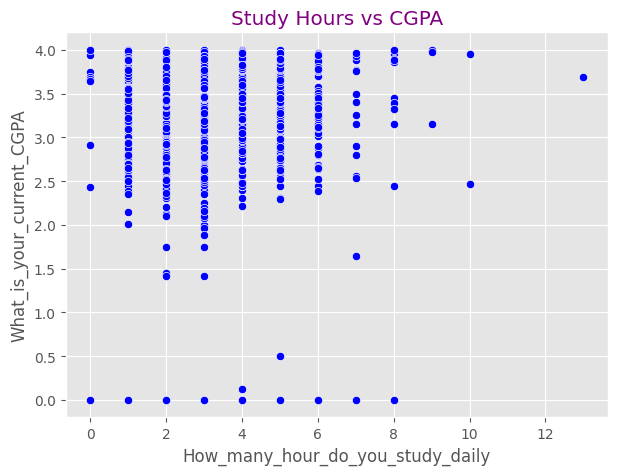

In [20]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='How_many_hour_do_you_study_daily',
    y='What_is_your_current_CGPA',
    data=df,
    color='blue'
)
plt.title("Study Hours vs CGPA", color='purple')
plt.show()

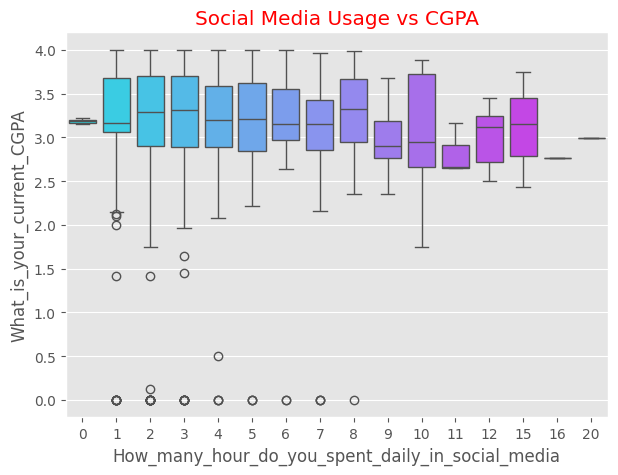

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x='How_many_hour_do_you_spent_daily_in_social_media',
    y='What_is_your_current_CGPA',
    data=df,
    palette='cool'
)
plt.title("Social Media Usage vs CGPA", color='red')
plt.show()

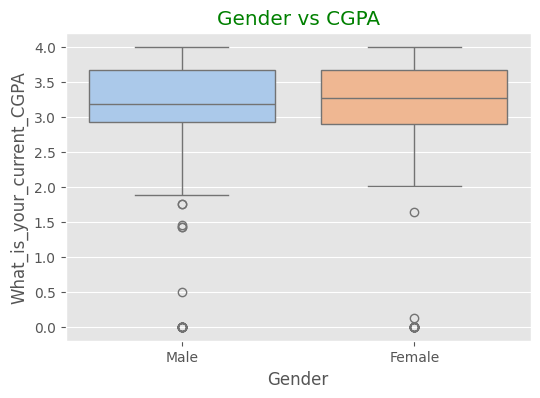

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='Gender',
    y='What_is_your_current_CGPA',
    data=df,
    palette='pastel'
)
plt.title("Gender vs CGPA", color='green')
plt.show()

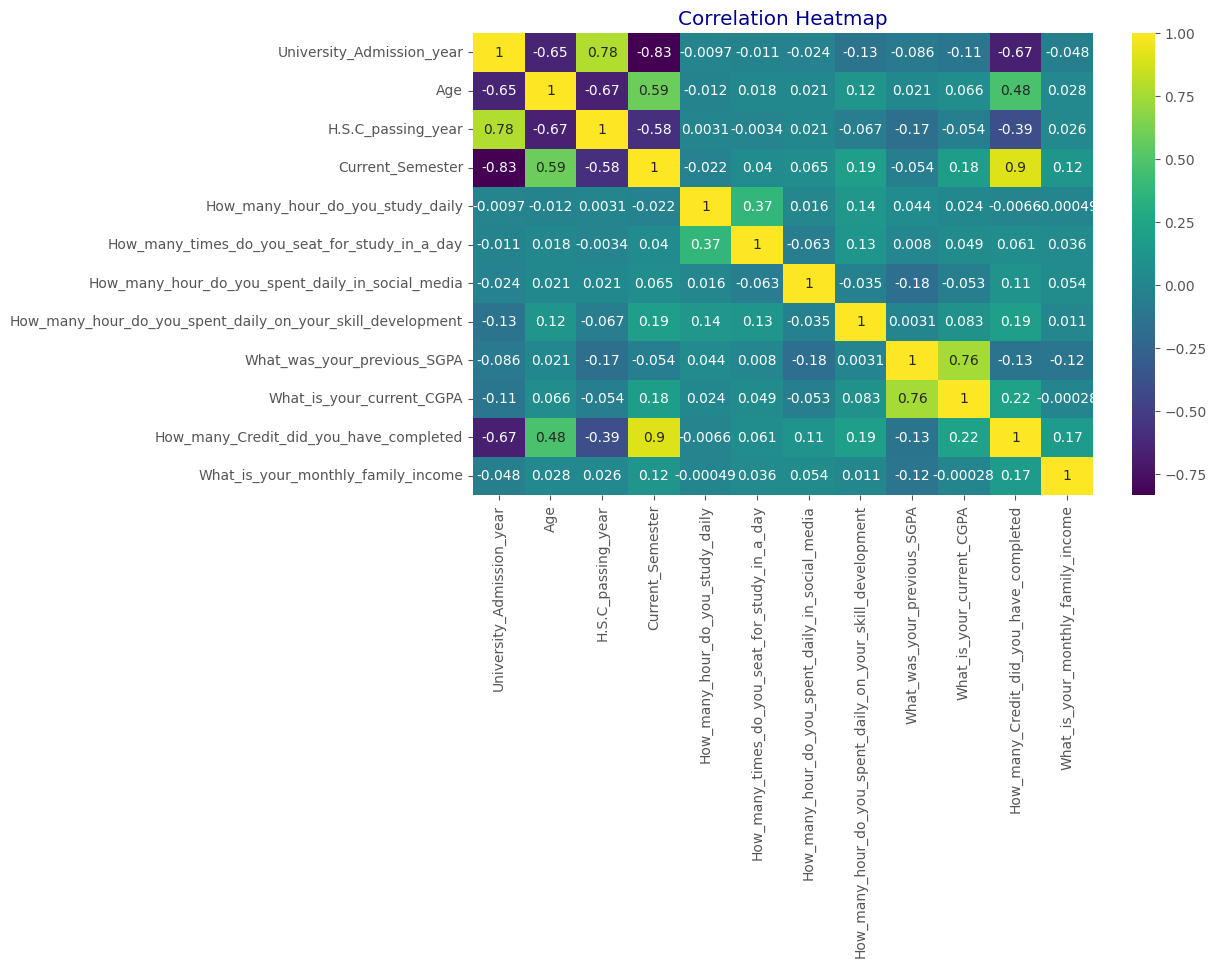

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='viridis')
plt.title("Correlation Heatmap", color='darkblue')
plt.show()

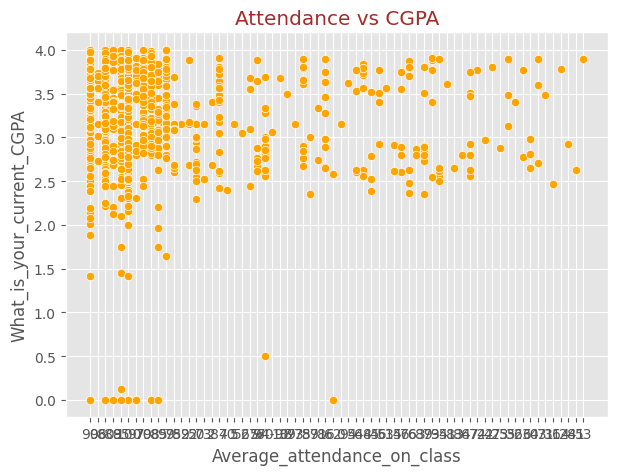

In [24]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='Average_attendance_on_class',
    y='What_is_your_current_CGPA',
    data=df,
    color='orange'
)
plt.title("Attendance vs CGPA", color='brown')
plt.show()

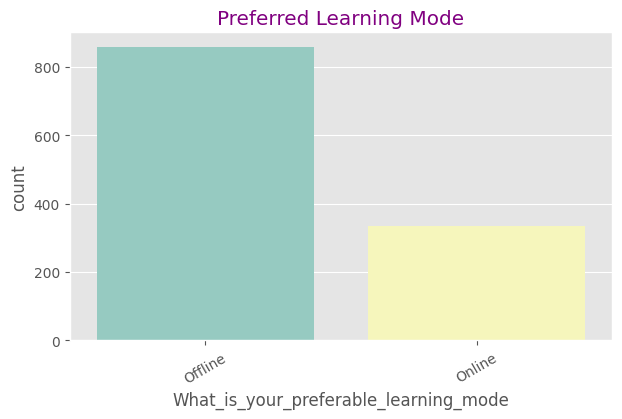

In [25]:
plt.figure(figsize=(7,4))
sns.countplot(
    x='What_is_your_preferable_learning_mode',
    data=df,
    palette='Set3'
)
plt.title("Preferred Learning Mode", color='purple')
plt.xticks(rotation=30)
plt.show()

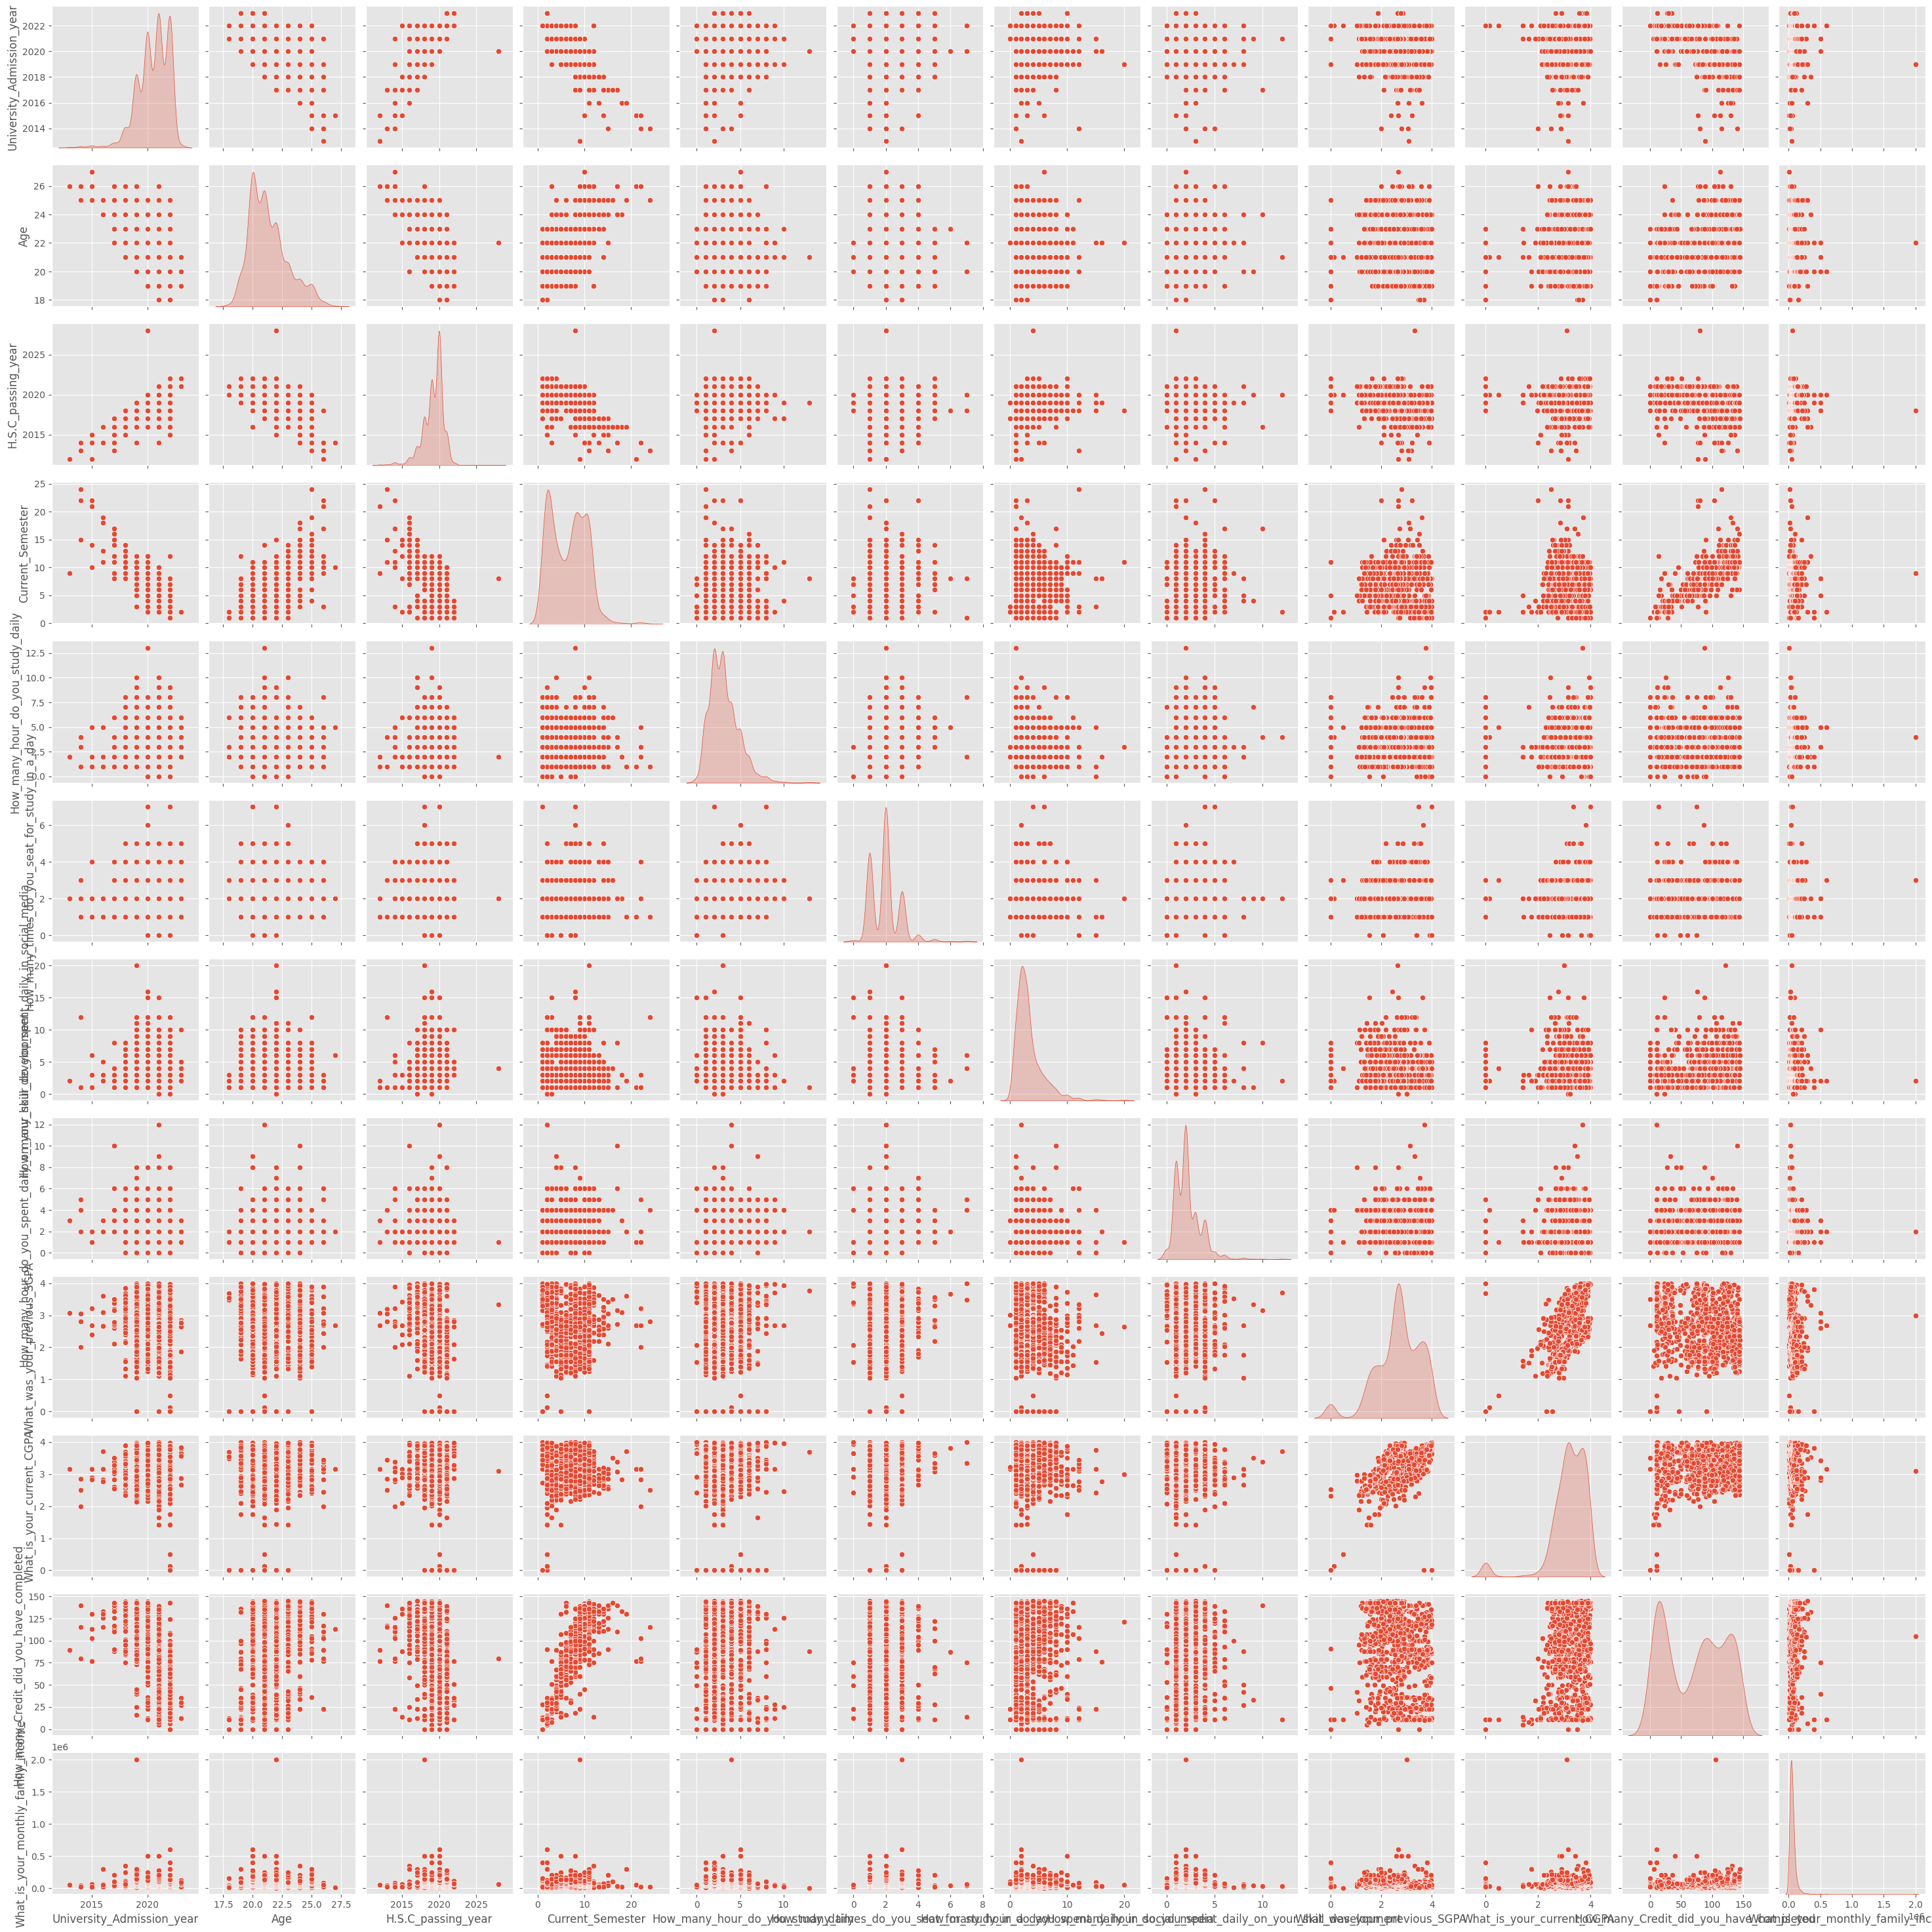

In [26]:
sns.pairplot(df[num_cols], diag_kind='kde')
plt.show()

In [27]:
print(df.columns.tolist())

['University_Admission_year', 'Gender', 'Age', 'H.S.C_passing_year', 'Program', 'Current_Semester', 'Do_you_have_meritorious_scholarship_', 'Do_you_use_University_transportation', 'How_many_hour_do_you_study_daily', 'How_many_times_do_you_seat_for_study_in_a_day', 'What_is_your_preferable_learning_mode', 'Do_you_use_smart_phone', 'Do_you_have_personal_Computer', 'How_many_hour_do_you_spent_daily_in_social_media', 'Status_of_your_English_language_proficiency', 'Average_attendance_on_class', 'Did_you_ever_fall_in_probation', 'Did_you_ever_got_suspension', 'Do_you_attend_in_teacher_consultancy_for_any_kind_of_academical_problems', 'What_are_the_skills_do_you_have_', 'How_many_hour_do_you_spent_daily_on_your_skill_development', 'What_is_you_interested_area', 'What_is_your_relationship_status', 'Are_you_engaged_with_any_co-curriculum_activities', 'With_whom_you_are_living_with', 'Do_you_have_any_health_issues', 'What_was_your_previous_SGPA', 'Do_you_have_any_physical_disabilities', 'What_is

## Feature engineering

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

In [29]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("?", "")
    .str.replace(".", "")
)

In [30]:
df = df.rename(columns={
    'What_is_your_current_CGPA': 'CGPA',
    'What_was_your_previous_SGPA': 'SGPA',
    'How_many_hour_do_you_study_daily': 'StudyHours',
    'How_many_times_do_you_seat_for_study_in_a_day': 'StudySessions',
    'What_is_your_monthly_family_income': 'Income'
})

# Verify columns
print("Columns:\n", df.columns)


Columns:
 Index(['University_Admission_year', 'Gender', 'Age', 'HSC_passing_year',
       'Program', 'Current_Semester', 'Do_you_have_meritorious_scholarship_',
       'Do_you_use_University_transportation', 'StudyHours', 'StudySessions',
       'What_is_your_preferable_learning_mode', 'Do_you_use_smart_phone',
       'Do_you_have_personal_Computer',
       'How_many_hour_do_you_spent_daily_in_social_media',
       'Status_of_your_English_language_proficiency',
       'Average_attendance_on_class', 'Did_you_ever_fall_in_probation',
       'Did_you_ever_got_suspension',
       'Do_you_attend_in_teacher_consultancy_for_any_kind_of_academical_problems',
       'What_are_the_skills_do_you_have_',
       'How_many_hour_do_you_spent_daily_on_your_skill_development',
       'What_is_you_interested_area', 'What_is_your_relationship_status',
       'Are_you_engaged_with_any_co-curriculum_activities',
       'With_whom_you_are_living_with', 'Do_you_have_any_health_issues',
       'SGPA', 'Do_you

In [31]:
df['CGPA_Class'] = df['CGPA'].apply(
    lambda x: 'High' if x >= df['CGPA'].median() else 'Low'
)


In [32]:
X = df.drop(columns=['CGPA', 'CGPA_Class'])
y = df['CGPA_Class']


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
encoders = {}

for col in X_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    
    X_train[col] = le.fit_transform(X_train[col])
    
    # Handle unseen values
    X_test[col] = X_test[col].map(lambda s: '<UNK>' if s not in le.classes_ else s)
    le.classes_ = np.append(le.classes_, '<UNK>')
    X_test[col] = le.transform(X_test[col])
    
    encoders[col] = le


In [35]:
target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

In [36]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [37]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [38]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)


Model Accuracy: 0.8661087866108786


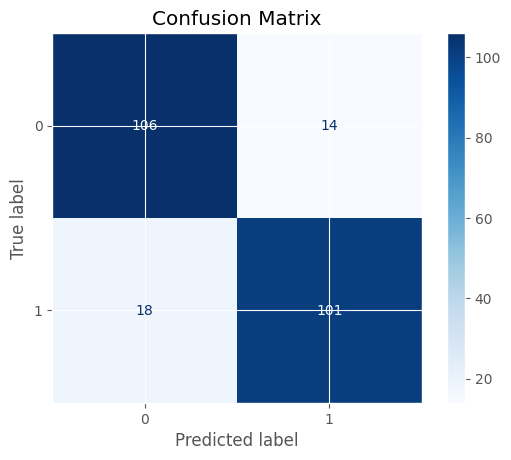

In [40]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

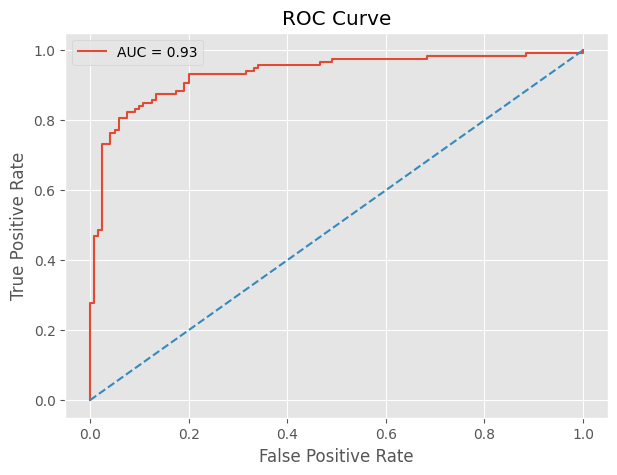

In [41]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Thank you...pls upvote!!!!!!